# Simple LInear Regression 

In [1]:
import pandas as pd
import numpy as nnp
import matplotlib.pyplot as plt

%matplotlib inline 

In [3]:
## Read the dataset 
df=pd.read_csv('height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

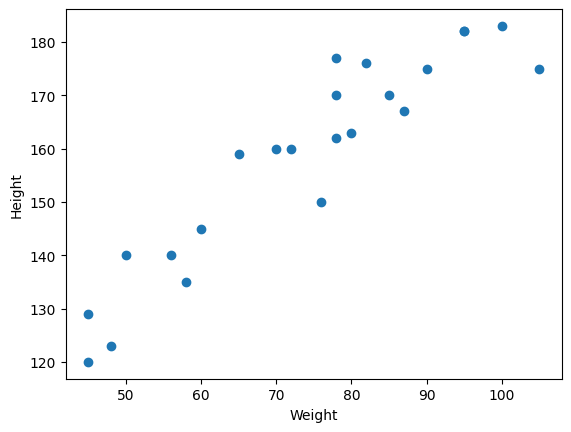

In [6]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')

In [26]:
## divide our dataset into independent and dependent features
x=df[['Weight']] # independent features
y=df['Height'] # Dependent features

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [29]:
x_train.shape,x_test.shape , y_train.shape,y_test.shape

((18, 1), (5, 1), (18,), (5,))

In [30]:
## standardize the dataset Train independent data
from sklearn.preprocessing import StandardScaler

In [31]:
scaler=StandardScaler()

In [38]:
X_train=scaler.fit_transform(x_train)
X_test=scaler.transform(x_test)

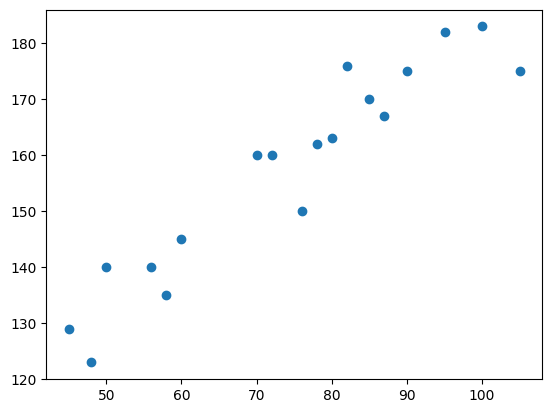

In [40]:
plt.scatter(x_train,y_train)

In [41]:
## Train the Simple Linear Regression Model 
from sklearn.linear_model import LinearRegression 

In [42]:
linear=LinearRegression ()

In [43]:
linear.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [44]:
print('The slope or coefficient of weight is ',linear.coef_)
print('Intercept : ', linear.intercept_)

The slope or coefficient of weight is  [0.9630459]
Intercept :  85.96709053063559


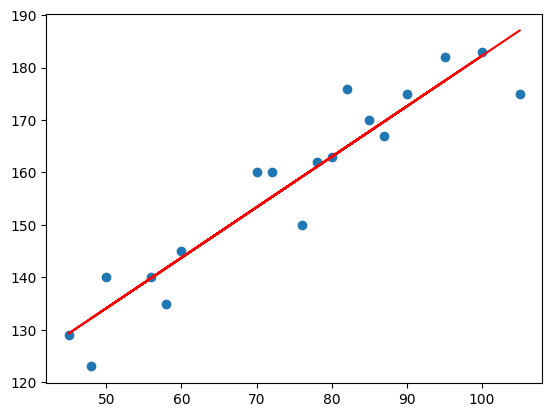

In [50]:
plt.scatter(x_train,y_train)
plt.plot(x_train,linear.predict(x_train),'r')

In [51]:
y_pred_test=linear.predict(x_test)
y_pred_test

array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
       148.56507414])

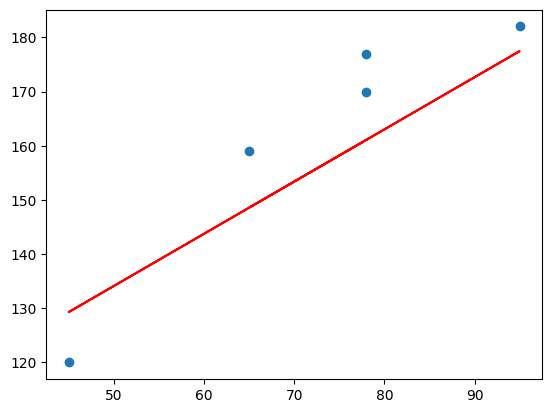

In [52]:
plt.scatter(x_test,y_test)
plt.plot(x_test,linear.predict(x_test),'r')

## Performance Metrics 

### MSE , MAE, RMSE,R square and adjusted R-square

In [56]:
from sklearn.metrics import mean_squared_error,mean_absolute_error
import numpy as np

In [57]:
mse=mean_squared_error(y_test,y_pred_test)
mae=mean_absolute_error(y_test,y_pred_test)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

109.77592599051658
9.822657814519232
10.477400726827078


## R Square 
### Formula 
### R^2 = 1-SSR/SST
### R^2 = coefficient of determination SSR=sum of squares of residuals SST= total sum of squares

In [58]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred_test)
score

0.776986986042344

## Adjusted R-square 

In [61]:
adj_r2 = 1 - (1 - score) * (len(y_test) - 1) / (len(y_test) - x_test.shape[1] - 1)


In [62]:
adj_r2

0.7026493147231252

In [63]:
linear

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [65]:
## new data point weight is 80

scaled_weight=scaler.transform([[80]])
scaled_weight

C:\Users\Madhav Yadav\myenv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.32350772]])

In [67]:
linear.predict([scaled_weight[0]])

C:\Users\Madhav Yadav\myenv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([86.27864331])

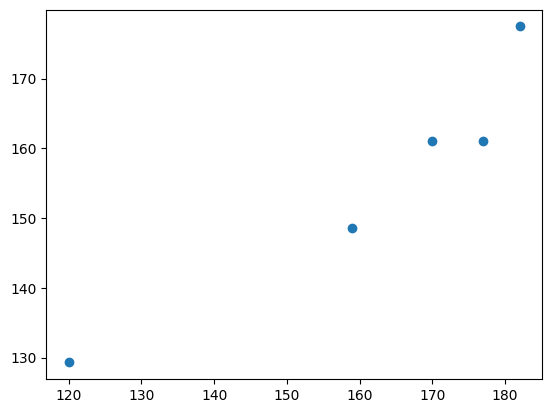

In [70]:
### Assumptions 
## plot a scatter plot for the prediction 
plt.scatter(y_test,y_pred_test)


In [71]:
## Residuals

residuals = y_test - y_pred_test
residuals

15    15.915329
9      8.915329
0     -9.304156
8      4.543549
17    10.434926
Name: Height, dtype: float64

C:\Users\Madhav Yadav\AppData\Local\Temp\ipykernel_14916\1450015181.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals,kde=True)


<Axes: xlabel='Height', ylabel='Density'>

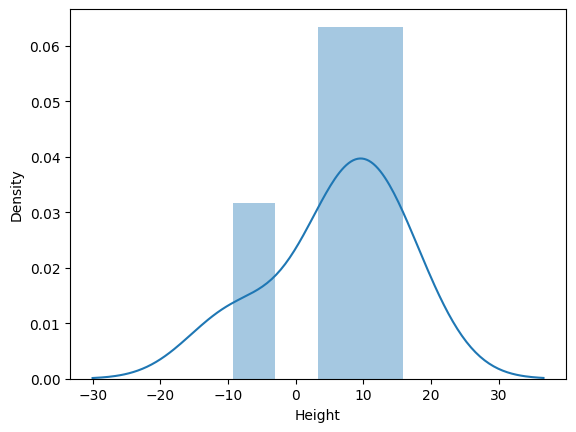

In [73]:
## plot this residuals 
import seaborn as sns
sns.distplot(residuals,kde=True)

In [ ]:
## scatter plot with respect to prediction and residuals 
## uniform distribution 
plt.scatter(y_pred_test,residu